# TASK #1: UNDERSTAND THE PROBLEM STATEMENT AND BUSINESS CASE

Data Source: https://www.kaggle.com/arjunbhasin2013/ccdata

The Bank has extensive data on their customers for last 6  months
The Marketing Team at the Bank wants to launch a targeted marketing campaign by dividing their customers into at least 3 distintive group

Understanding Dataset and variables






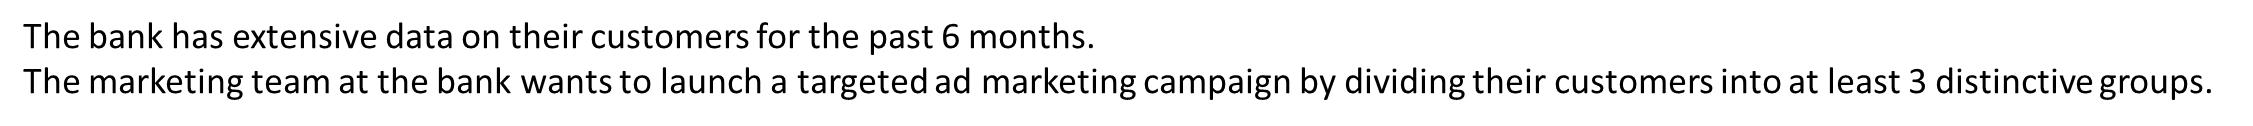
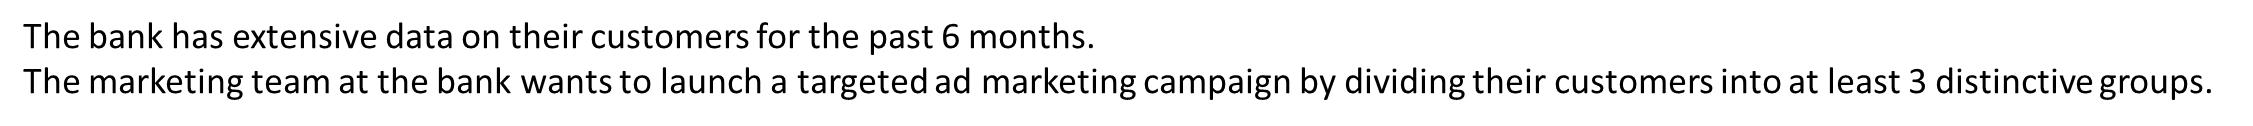
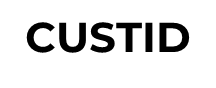
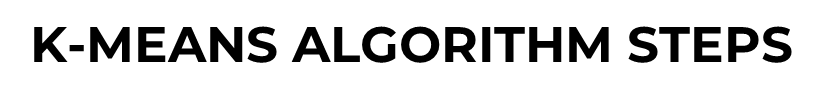
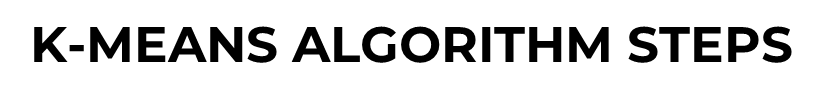

In [1]:
# CUSTID: Identification of Credit Card holder
# BALANCE: Balance amount left in customer's account to make purchases
# BALANCE_FREQUENCY: How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
# PURCHASES: Amount of purchases made from account
# ONEOFFPURCHASES: Maximum purchase amount done in one-go
# INSTALLMENTS_PURCHASES: Amount of purchase done in installment
# CASH_ADVANCE: Cash in advance given by the user
# PURCHASES_FREQUENCY: How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
# ONEOFF_PURCHASES_FREQUENCY: How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)
# PURCHASES_INSTALLMENTS_FREQUENCY: How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)
# CASH_ADVANCE_FREQUENCY: How frequently the cash in advance being paid
# CASH_ADVANCE_TRX: Number of Transactions made with "Cash in Advance"
# PURCHASES_TRX: Number of purchase transactions made
# CREDIT_LIMIT: Limit of Credit Card for user
# PAYMENTS: Amount of Payment done by user
# MINIMUM_PAYMENTS: Minimum amount of payments made by user
# PRC_FULL_PAYMENT: Percent of full payment paid by user
# TENURE: Tenure of credit card service for user

# TASK #2: IMPORT LIBRARIES AND DATASETS

In [21]:
# The the dataset and explore it
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# You have to include the full link to the csv file containing your dataset
creditcard_df = pd.read_csv('Marketing_dataset.csv')
creditcard_df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
creditcard_df.info()
# 18 features with 8950 points

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
creditcard_df.describe()
# Mean balance is $1564
# Balance frequency is frequently updated on average ~0.9
# Purchases average is $1000
# one off purchase average is ~$600
# Average purchases frequency is around 0.5
# average ONEOFF_PURCHASES_FREQUENCY, PURCHASES_INSTALLMENTS_FREQUENCY, and CASH_ADVANCE_FREQUENCY are generally low
# Average credit limit ~ 4500
# Percent of full payment is 15%
# Average tenure is 11 years

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [6]:
# Find the one who made one off purchase of $40761! (Max)
# Intuitive of python code: Find the person in the Dataset, that person has 'ONEOFF_PURCHASES is MAX (= 40761.25)
creditcard_df[creditcard_df['ONEOFF_PURCHASES'] == 40761.25]
#creditcard_df[creditcard_df['ONEOFF_PURCHASES'] == 40761.25]
#Found the CUST_ID = C10574

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
550,C10574,11547.52001,1.0,49039.57,40761.25,8278.32,558.166886,1.0,1.0,0.916667,0.083333,1,101,22500.0,46930.59824,2974.069421,0.25,12


In [7]:
# Find the CUST_ID has the Max Cash Advance
creditcard_df['CASH_ADVANCE'].max()


np.float64(47137.21176)

In [8]:
# Let's find who made cash advance of $47137! Quite high
# This customer made 123 cash advance transactions!!
# Never paid credit card in full
creditcard_df[creditcard_df['CASH_ADVANCE'] == 47137.21176]


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
2159,C12226,10905.05381,1.0,431.93,133.5,298.43,47137.21176,0.583333,0.25,0.5,1.0,123,21,19600.0,39048.59762,5394.173671,0.0,12


# TASK #3: EXPLORE DATASET (VISUALIZATION OF THIS DATASET CAN BE SEEN IN OTHER GIT - VISUALIZATION OF_MARKETING_CREDIT SCORE)

In [22]:
# Let check how  many data points is NULL and count total number
creditcard_df.isnull().sum()
# We found: MINIMUM_PAYMENTS : 313 data points missing + CREDIT_LIMIT: 1

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [23]:
# Replace the missing elements with mean of the 'MINIMUM_PAYMENT' # Practical/Rules of Thumbs
creditcard_df.loc[(creditcard_df['MINIMUM_PAYMENTS'].isnull() ==True), 'MINIMUM_PAYMENTS'] = creditcard_df['MINIMUM_PAYMENTS'].mean()
#creditcard_df.loc[(creditcard_df['MINIMUM_PAYMENTS'].isnull() == True),
 #                               'MINIMUM_PAYMENTS'] = creditcard_df['MINIMUM_PAYMENTS'].mean()


In [24]:
# We replace the missing elements with mean of the 'CREDIT_LIMIT'
creditcard_df.loc[(creditcard_df['CREDIT_LIMIT'].isnull() == True), 'CREDIT_LIMIT'] = creditcard_df['CREDIT_LIMIT'].mean()
#creditcard_df.loc[(creditcard_df['CREDIT_LIMIT'].isnull() == True), 'CREDIT_LIMIT'] = creditcard_df['CREDIT_LIMIT'].mean()

In [25]:
# Let's see if we have duplicated entries in the data
creditcard_df.duplicated().sum()
#Luckyli not DUPLICATED Data points

np.int64(0)

In [29]:
# We found that the Customer ID since it has no meaning here. let's drop
print(creditcard_df.columns)

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')


In [16]:
creditcard_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [31]:
n = len(creditcard_df.columns)
n

17

In [33]:
creditcard_df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

# TASK #4: FIND THE OPTIMAL NUMBER OF CLUSTERS USING ELBOW METHOD

- The elbow method is a heuristic method of interpretation and validation of consistency within cluster analysis designed to help find the appropriate number of clusters in a dataset.
- If the line chart looks like an arm, then the "elbow" on the arm is the value of k that is the best.


In [35]:
# Let's scale the data first
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
creditcard_df_scaled = scaler.fit_transform(creditcard_df)

In [36]:
creditcard_df_scaled.shape

(8950, 17)

In [37]:
creditcard_df_scaled

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]], shape=(8950, 17))

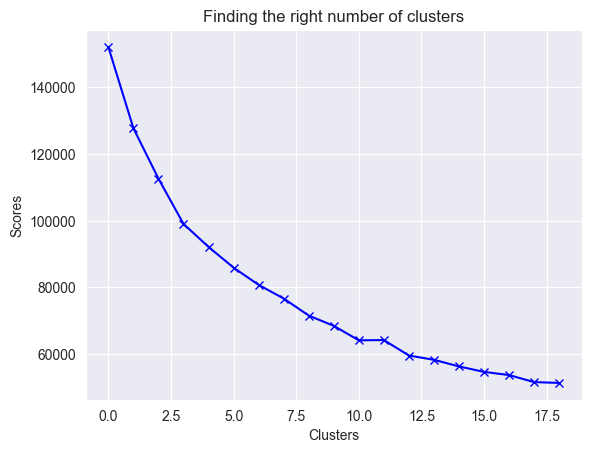

In [42]:
scores_1 = []

range_values = range(1, 20)
from sklearn.cluster import KMeans
for i in range_values:
  kmeans = KMeans(n_clusters = i)
  kmeans.fit(creditcard_df_scaled)
  scores_1.append(kmeans.inertia_)

plt.plot(scores_1, 'bx-')
plt.title('Finding the right number of clusters')
plt.xlabel('Clusters')
plt.ylabel('Scores')
plt.show()

# From this we can observe that, 4th cluster seems to be forming the elbow of the curve.
# However, the values does not reduce linearly until 8th cluster.
# Let's choose the number of clusters to be 7.

# TASK #5: APPLY K-MEANS METHOD

The Simple Analogy: "The Pizza Delivery Zones"
Imagine you own a pizza shop chain and you want to open 3 new locations (where $K=3$) in a big city to serve customers efficiently. You have a map of where all your potential customers live (the data points), but you don't know where to build the shops.

Guessing (Initialization): You blindly stick 3 pins on the map at random spots and say, "These are my delivery centers."

Assigning Customers (Assignment Step): Every customer calls the shop closest to their house. Now, the city is divided into 3 zones based on who is closest to which pin.
Moving the Shop (Update Step): You realize your random pins are bad locations (maybe one is in a lake). So, you calculate the exact center of all the customer houses in "Zone 1" and move the shop there to minimize travel time. You do the same for Zone 2 and Zone 3.
Repeat: Now that the shops have moved, some customers might find they are now closer to a different shop. So, they switch zones. You re-calculate the centers again. You keep doing this until the shops stop moving.​

That is K-Means Clustering.

STEP BY STEP TO DO K MEANS
1. Initialization: You choose $K$ (the number of clusters you want) and randomly place $K$ centroids (center points) in your data space.​

2. Assignment (The "Nearest Neighbor" Step): For every single data point, you calculate its distance (usually Euclidean) to each of the $K$ centroids. You assign the point to the cluster of the closest centroid.​

3. Update (The "Finding the Mean" Step): Once all points are assigned, you calculate the average (mean) position of all the points inside each cluster. You move the centroid to this new average position.​

4. Convergence: You repeat steps 2 and 3. As the centroids move, points might switch clusters. Eventually, the centroids stop moving because they have found the optimal center of their groups. The algorithm effectively minimizes the "variance" (distance squared) within each cluster.​

Key Limitation: The "K" Problem
The algorithm doesn't know how many clusters should exist. If you tell it $K=3$ for a dataset that clearly has 2 groups, it will force a split where none exists. This is why you often use the Elbow Method (plotting the error vs. K) to find the best $K$.

In [43]:
kmeans = KMeans(8)
kmeans.fit(creditcard_df_scaled)
labels = kmeans.labels_

In [44]:
kmeans.cluster_centers_.shape

(8, 17)

In [45]:

cluster_centers = pd.DataFrame(data = kmeans.cluster_centers_, columns = [creditcard_df.columns])
cluster_centers

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.341017,-0.353244,-0.284107,-0.208252,-0.288805,0.060611,-0.197115,-0.272432,-0.229047,0.294612,-0.006686,-0.385618,-0.560692,-0.391404,-0.210474,0.016345,-3.203362
1,0.133606,0.431192,0.963568,0.907983,0.610192,-0.297707,1.106177,1.878516,0.561336,-0.392824,-0.301138,1.231510,0.707352,0.412722,-0.047668,0.467411,0.304666
2,1.443847,0.414656,7.093187,6.244031,5.297641,0.004274,1.081960,1.867817,1.035380,-0.299540,-0.116878,4.699112,2.171463,4.847281,1.104788,0.830765,0.333341
3,-0.701491,-2.142104,-0.306804,-0.230217,-0.302367,-0.321127,-0.548184,-0.428970,-0.441250,-0.518431,-0.375032,-0.416643,-0.171023,-0.202339,-0.257105,0.295555,0.202634
4,-0.383092,0.330466,-0.038802,-0.233271,0.336650,-0.372816,0.993521,-0.356077,1.189544,-0.487606,-0.369958,0.174710,-0.279402,-0.227404,-0.038729,0.323507,0.251263
5,1.802246,0.279563,0.065475,0.049270,0.063928,4.777947,-0.257746,-0.000350,-0.188904,2.494220,4.059728,0.006060,1.409096,3.566288,0.593215,-0.134637,0.024711
6,-0.087819,0.396398,-0.336542,-0.217462,-0.396111,-0.175465,-0.781175,-0.311758,-0.742559,-0.021023,-0.119531,-0.455979,-0.361594,-0.264491,-0.071657,-0.446061,0.276300
7,1.466467,0.418697,-0.281711,-0.206210,-0.287315,1.259505,-0.576089,-0.285379,-0.501349,1.594645,1.316666,-0.330641,0.789073,0.252157,0.572931,-0.449547,0.113759


In [ ]:
# In order to understand what these numbers mean, let's perform inverse transformation
cluster_centers = scaler.inverse_transform(cluster_centers)
cluster_centers = pd.DataFrame(data = cluster_centers, columns = [creditcard_df.columns])
cluster_centers

# First Customers cluster (Transactors): Those are customers who pay least amount of intrerest charges and careful with their money, Cluster with lowest balance ($104) and cash advance ($303), Percentage of full payment = 23%
# Second customers cluster (revolvers) who use credit card as a loan (most lucrative sector): highest balance ($5000) and cash advance (~$5000), low purchase frequency, high cash advance frequency (0.5), high cash advance transactions (16) and low percentage of full payment (3%)
# Third customer cluster (VIP/Prime): high credit limit $16K and highest percentage of full payment, target for increase credit limit and increase spending habits
# Fourth customer cluster (low tenure): these are customers with low tenure (7 years), low balance


In [46]:
labels.shape # Labels associated to each data point

(8950,)

In [47]:
labels.max()

np.int32(7)

In [48]:
labels.min()

np.int32(0)

In [49]:
y_kmeans = kmeans.fit_predict(creditcard_df_scaled)
y_kmeans


array([4, 3, 2, ..., 6, 6, 6], shape=(8950,), dtype=int32)

In [50]:
# concatenate the clusters labels to our original dataframe
creditcard_df_cluster = pd.concat([creditcard_df, pd.DataFrame({'cluster':labels})], axis = 1)
creditcard_df_cluster.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,6
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,7
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,6
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,6


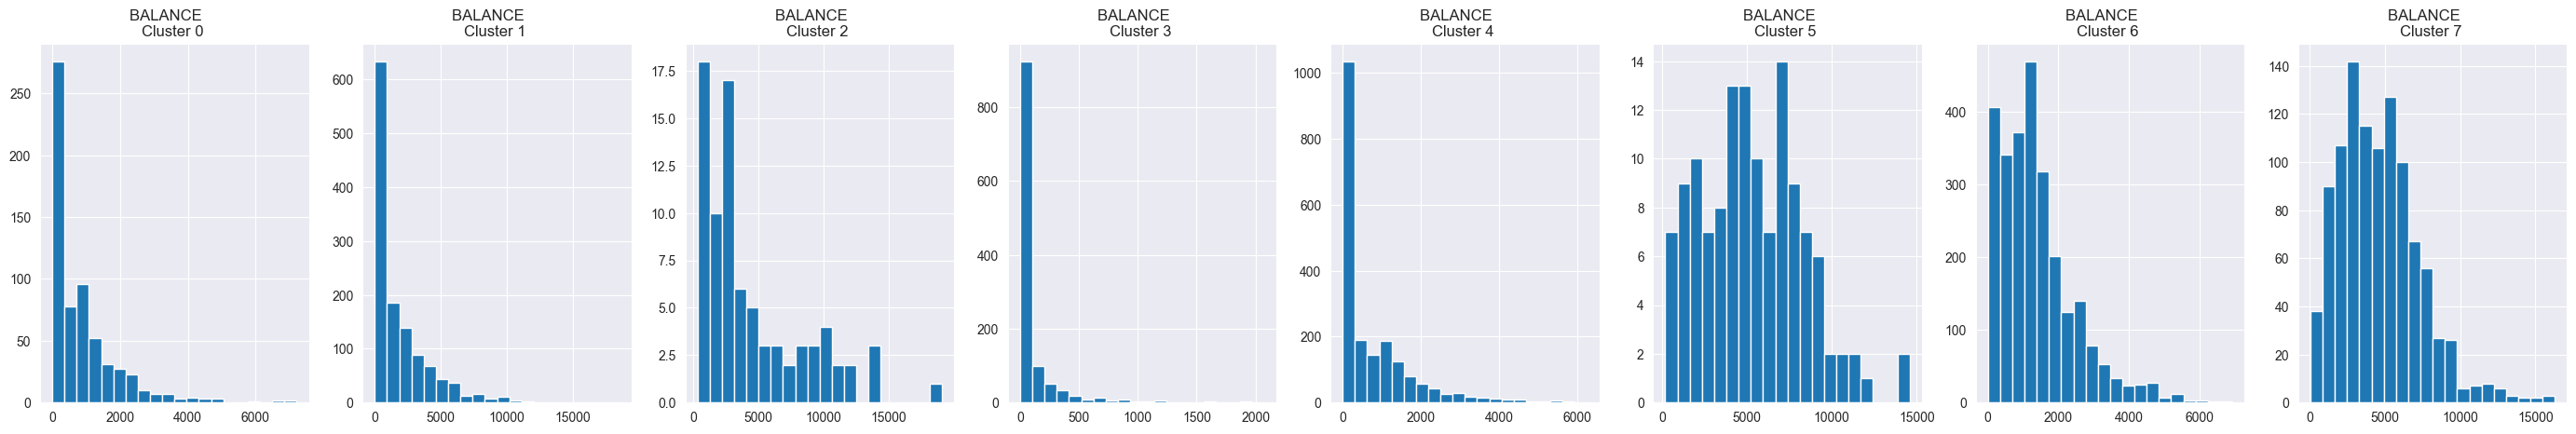

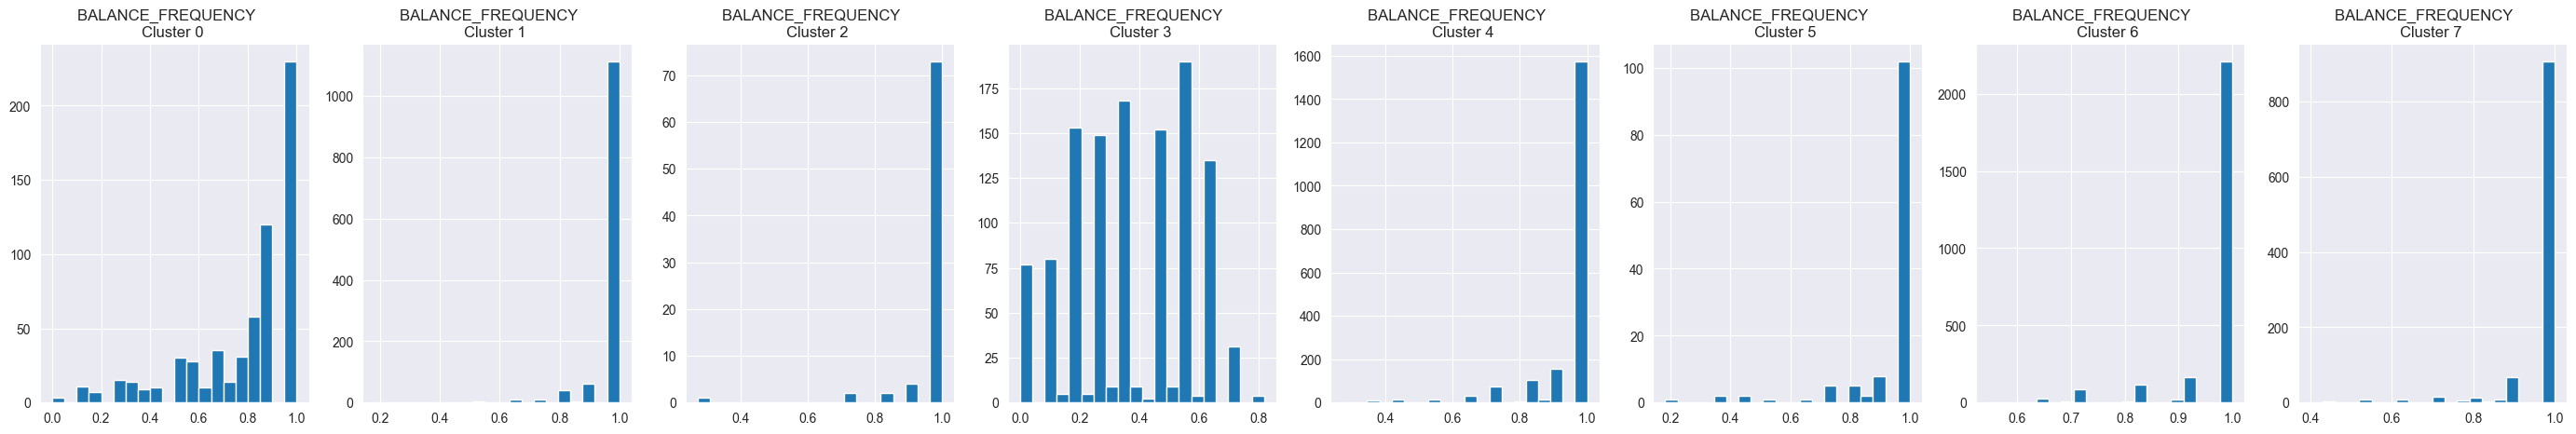

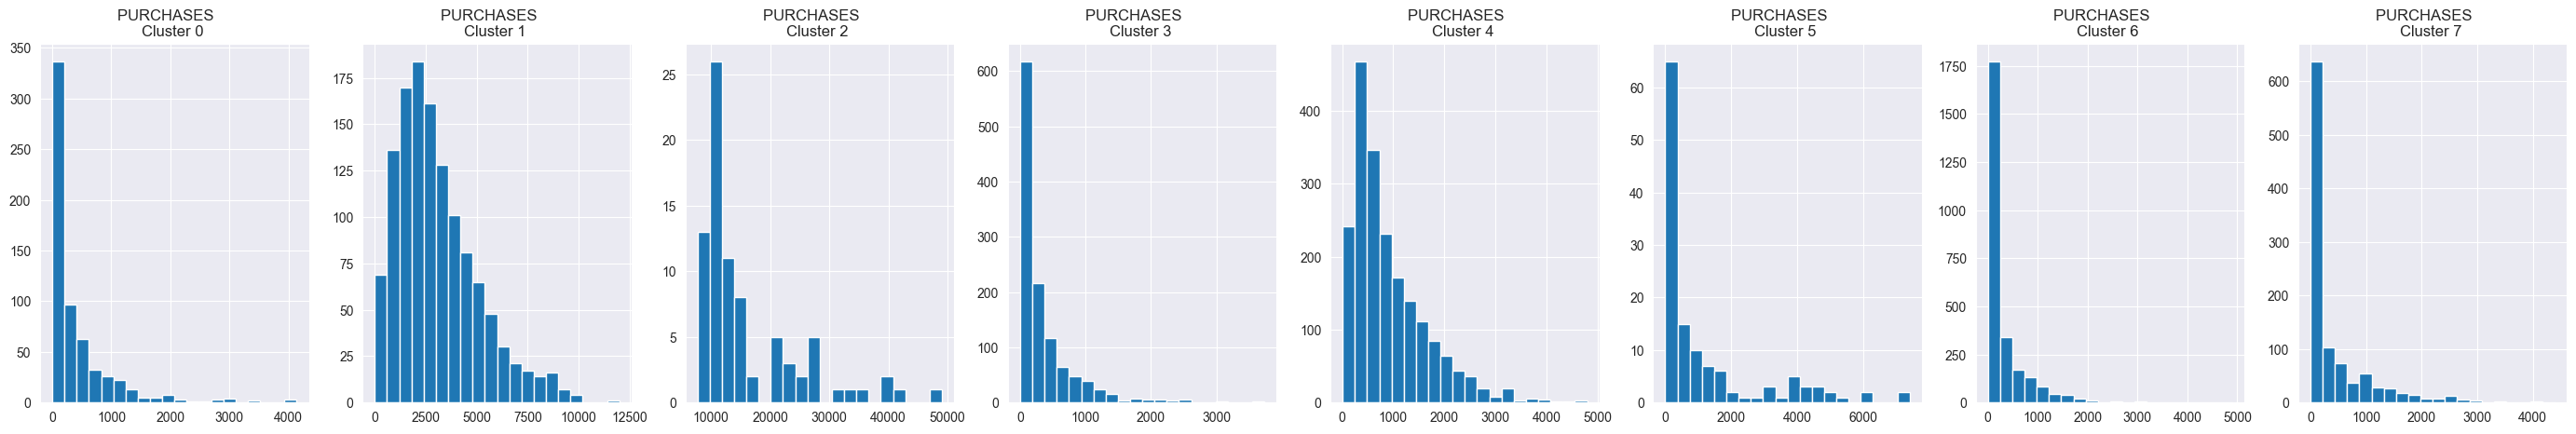

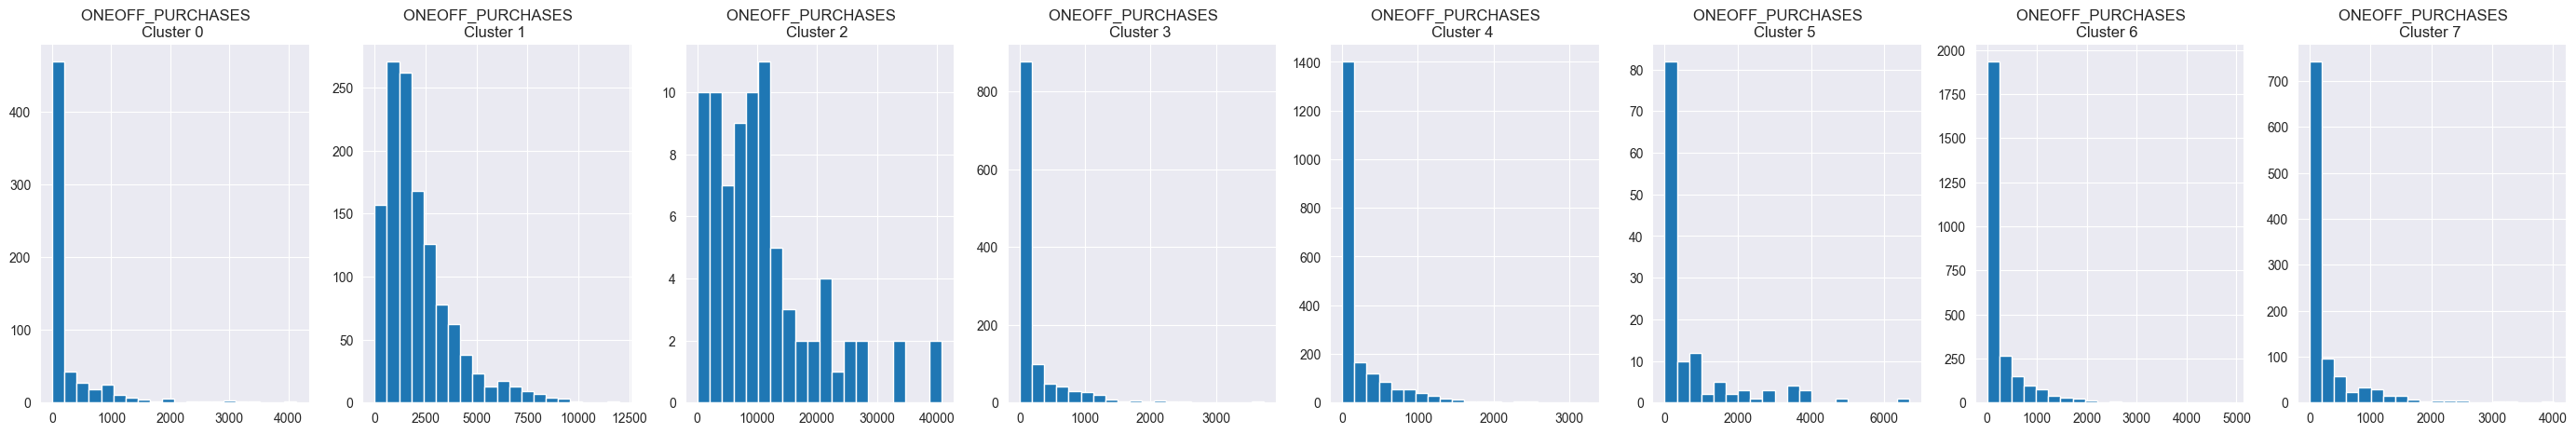

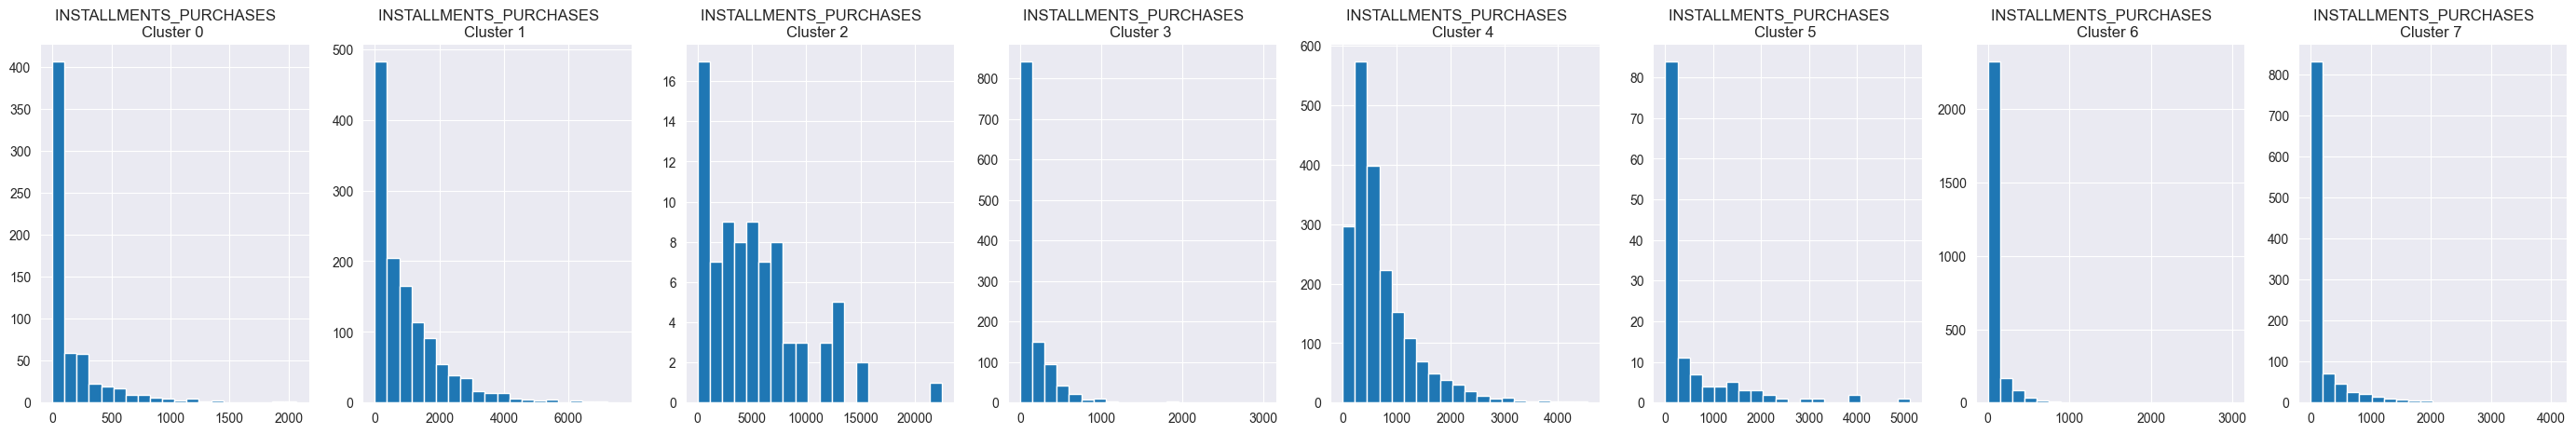

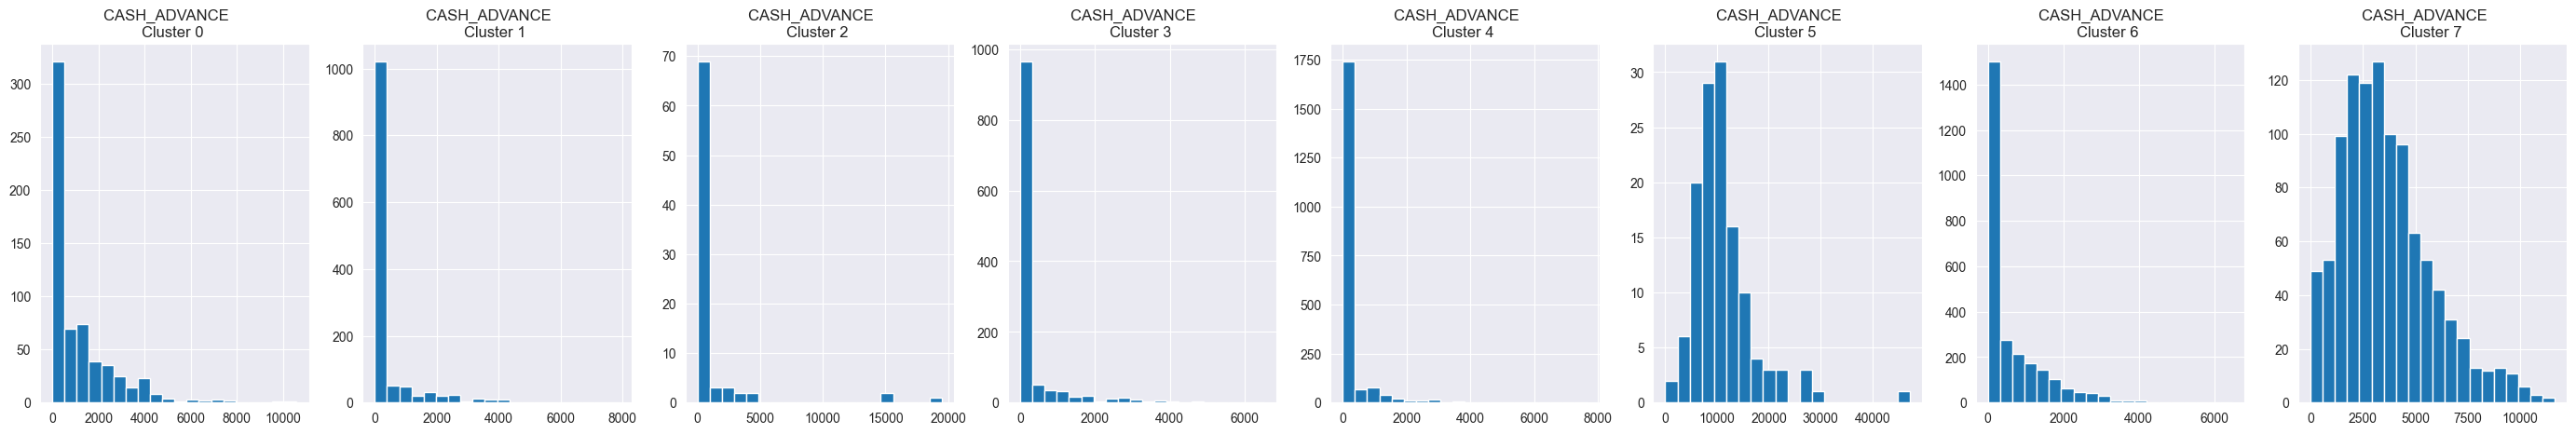

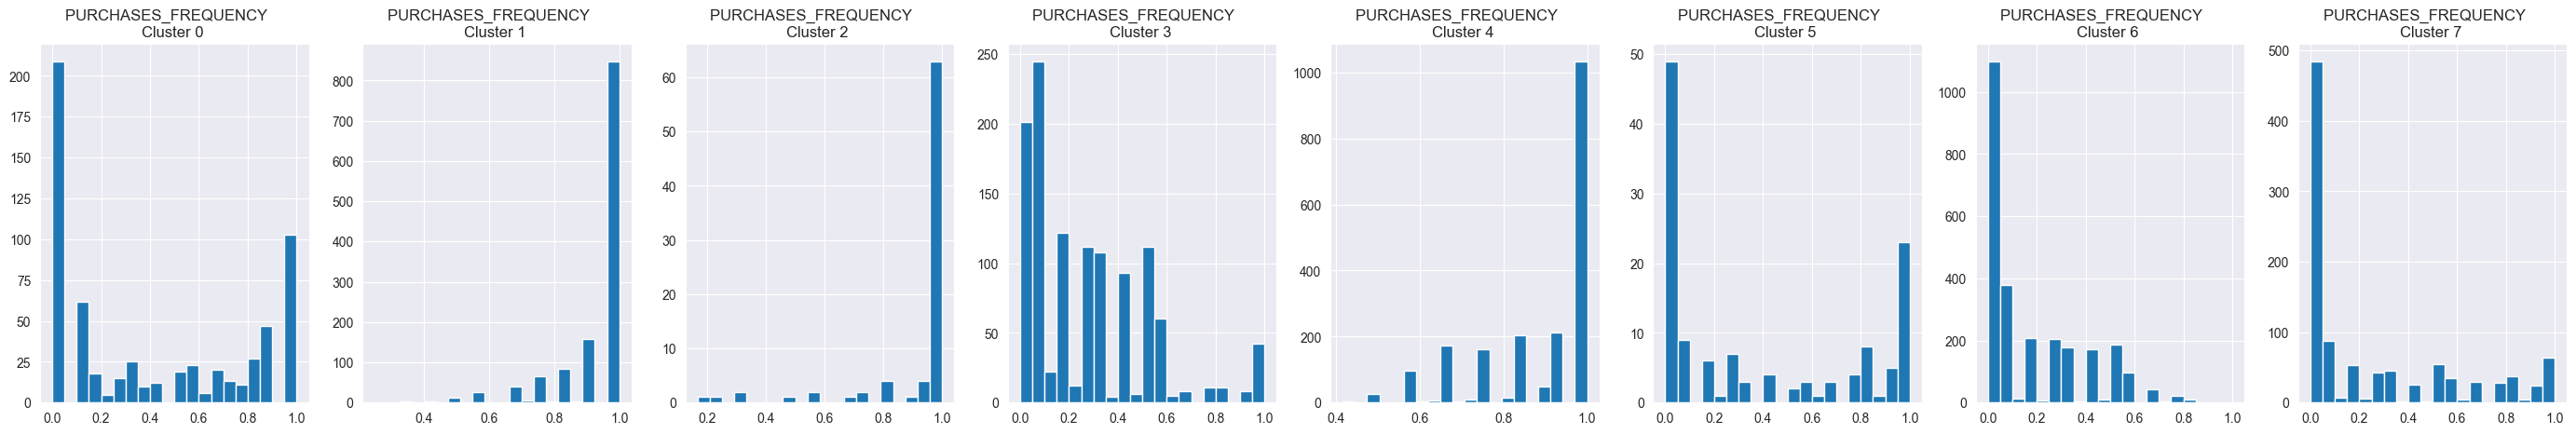

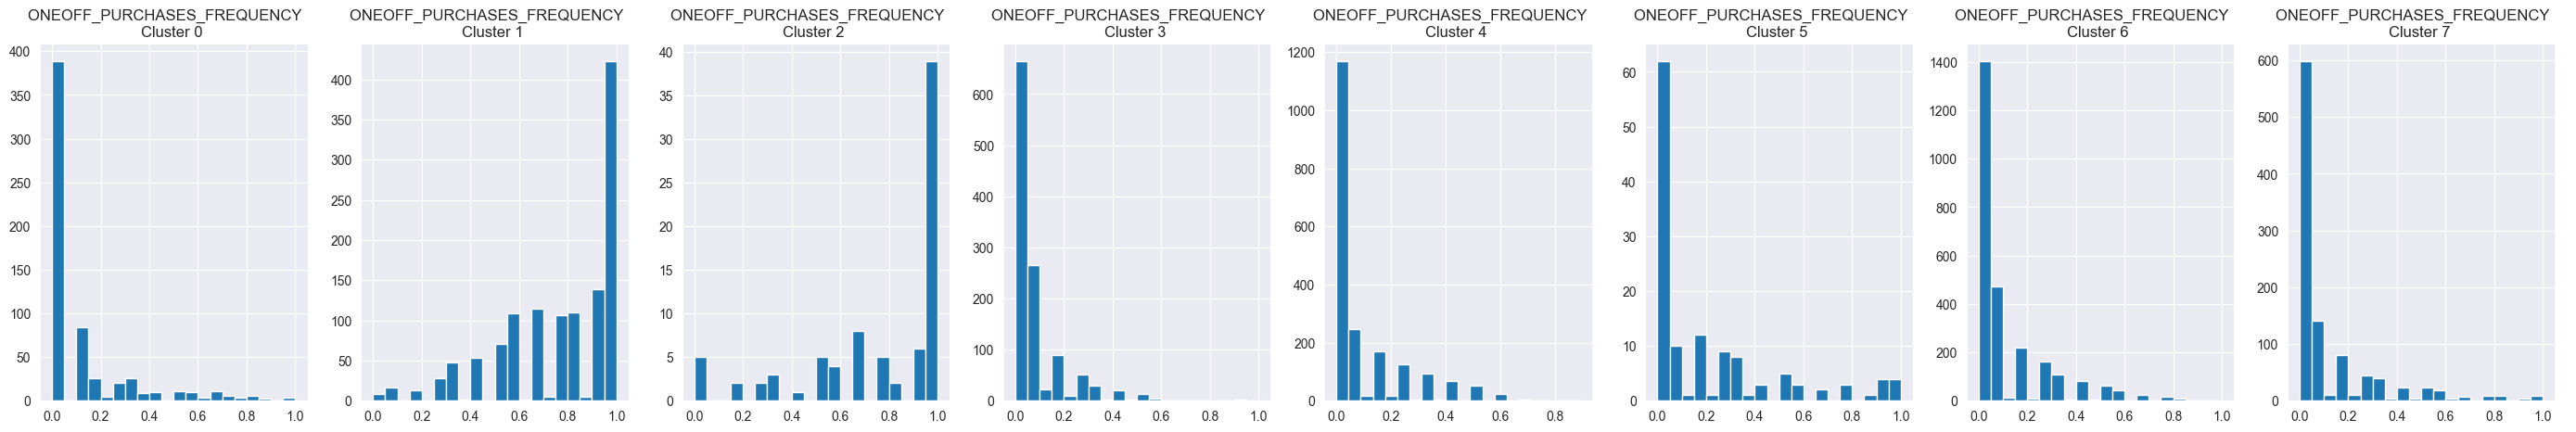

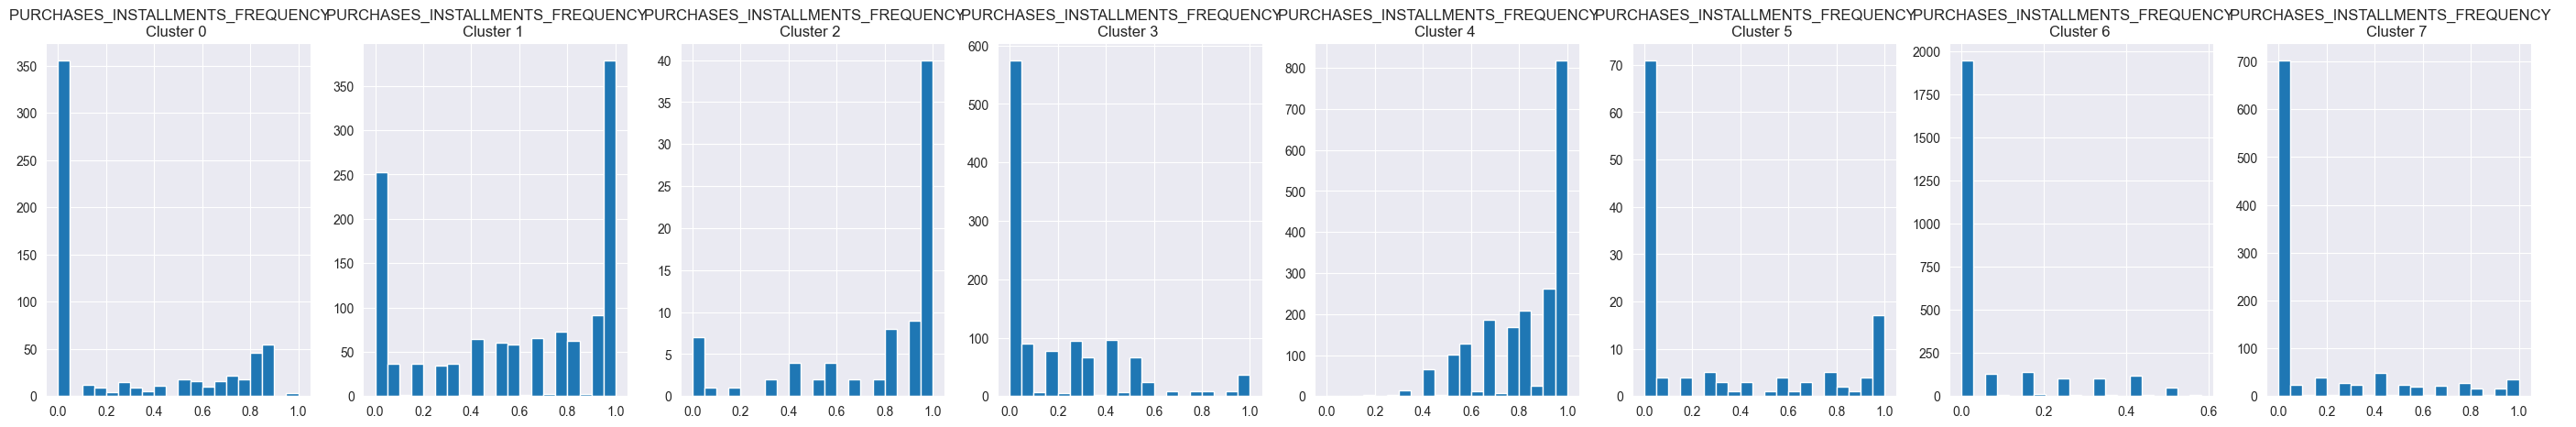

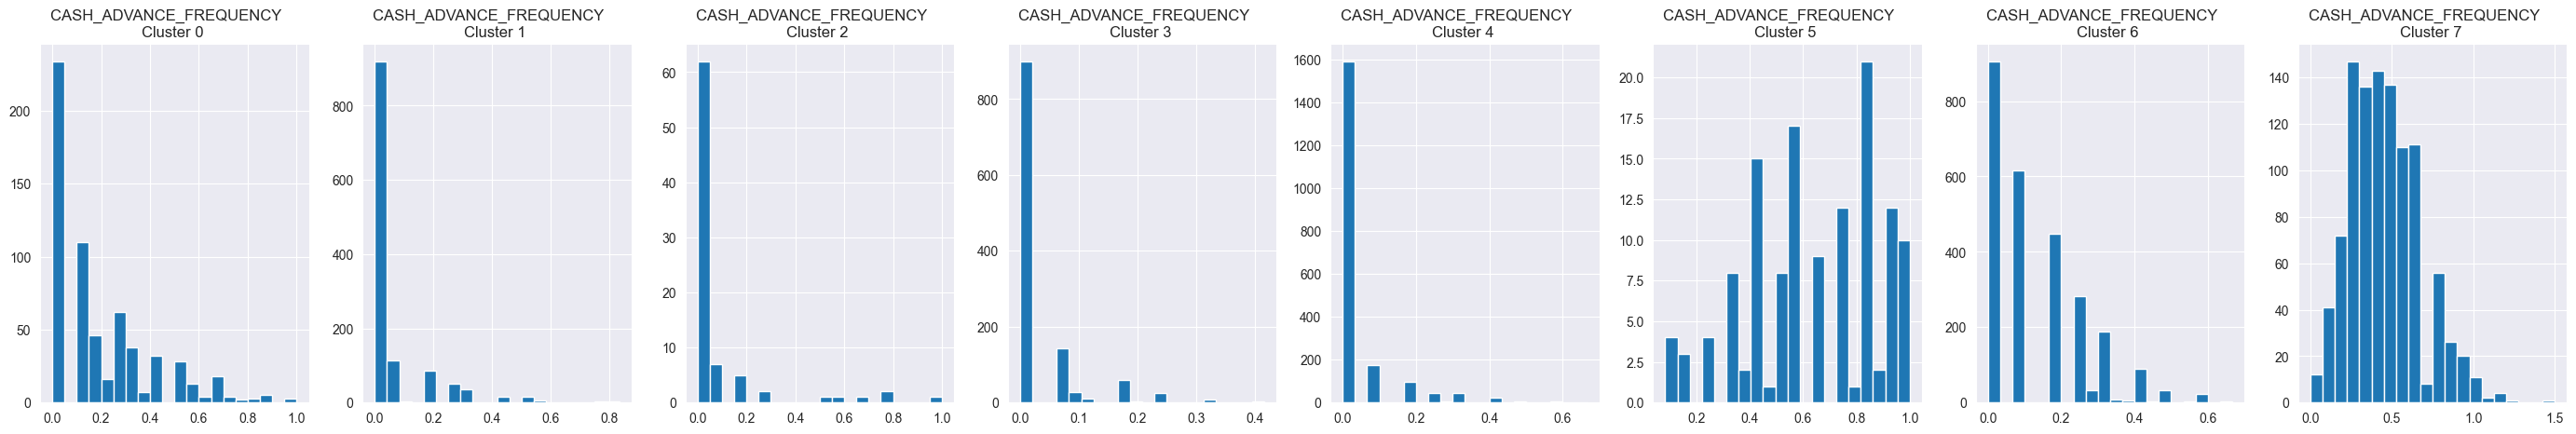

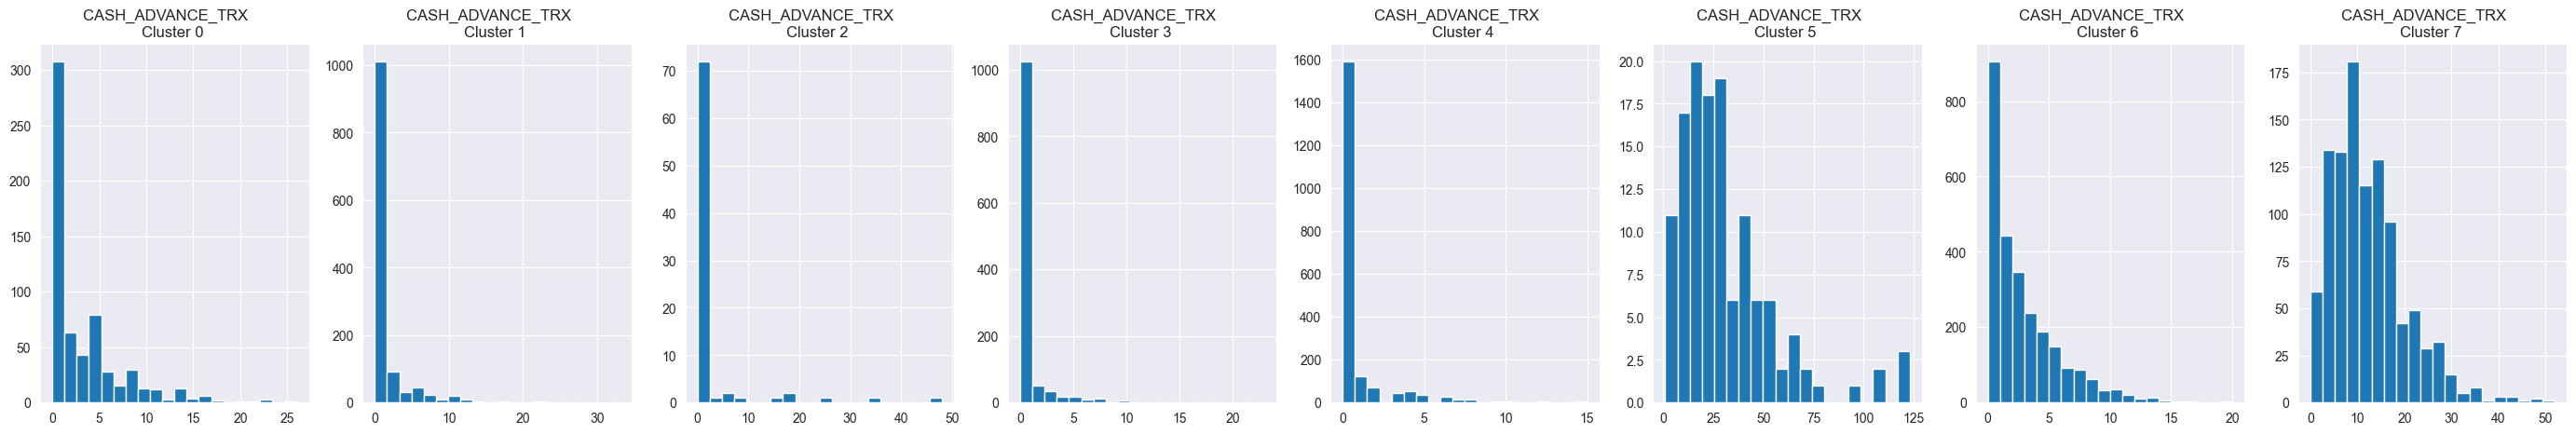

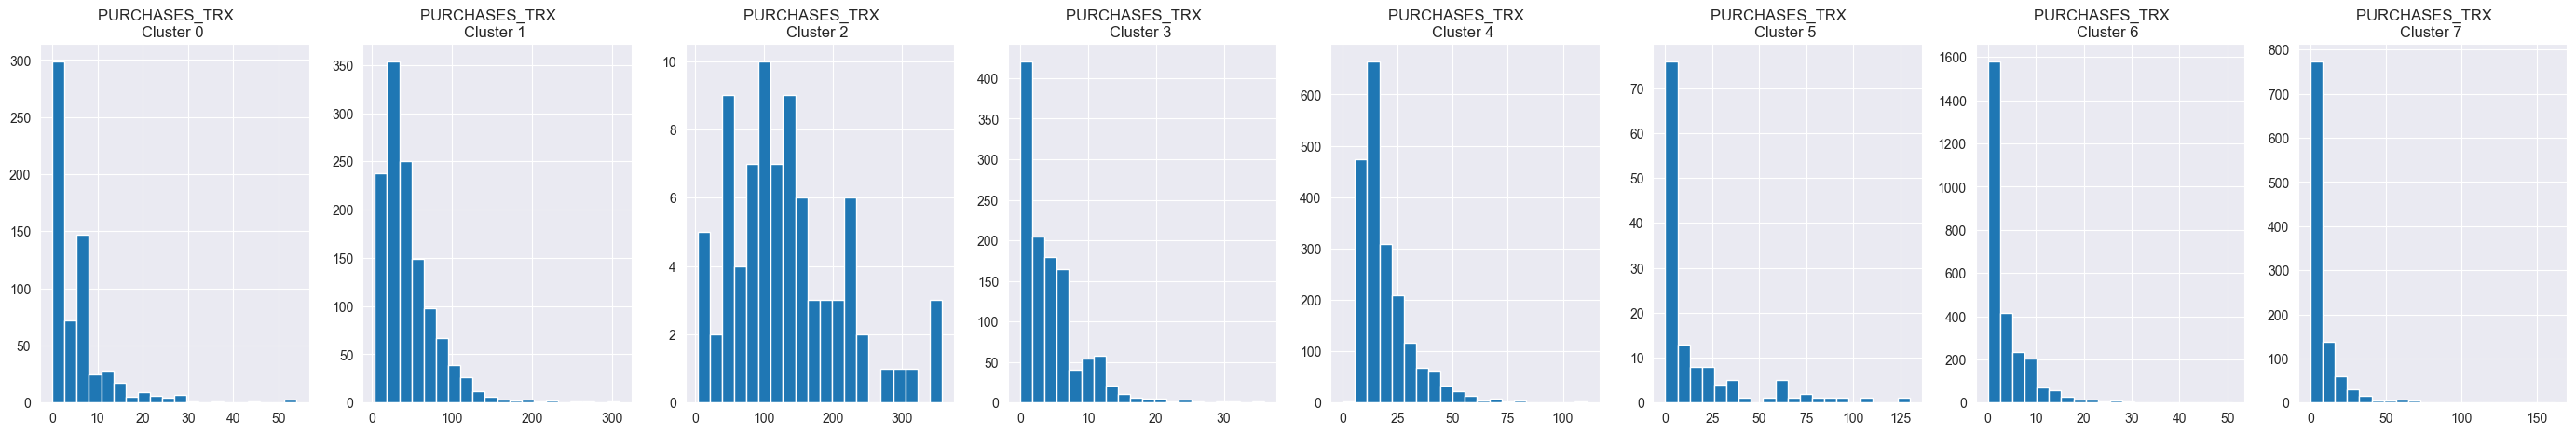

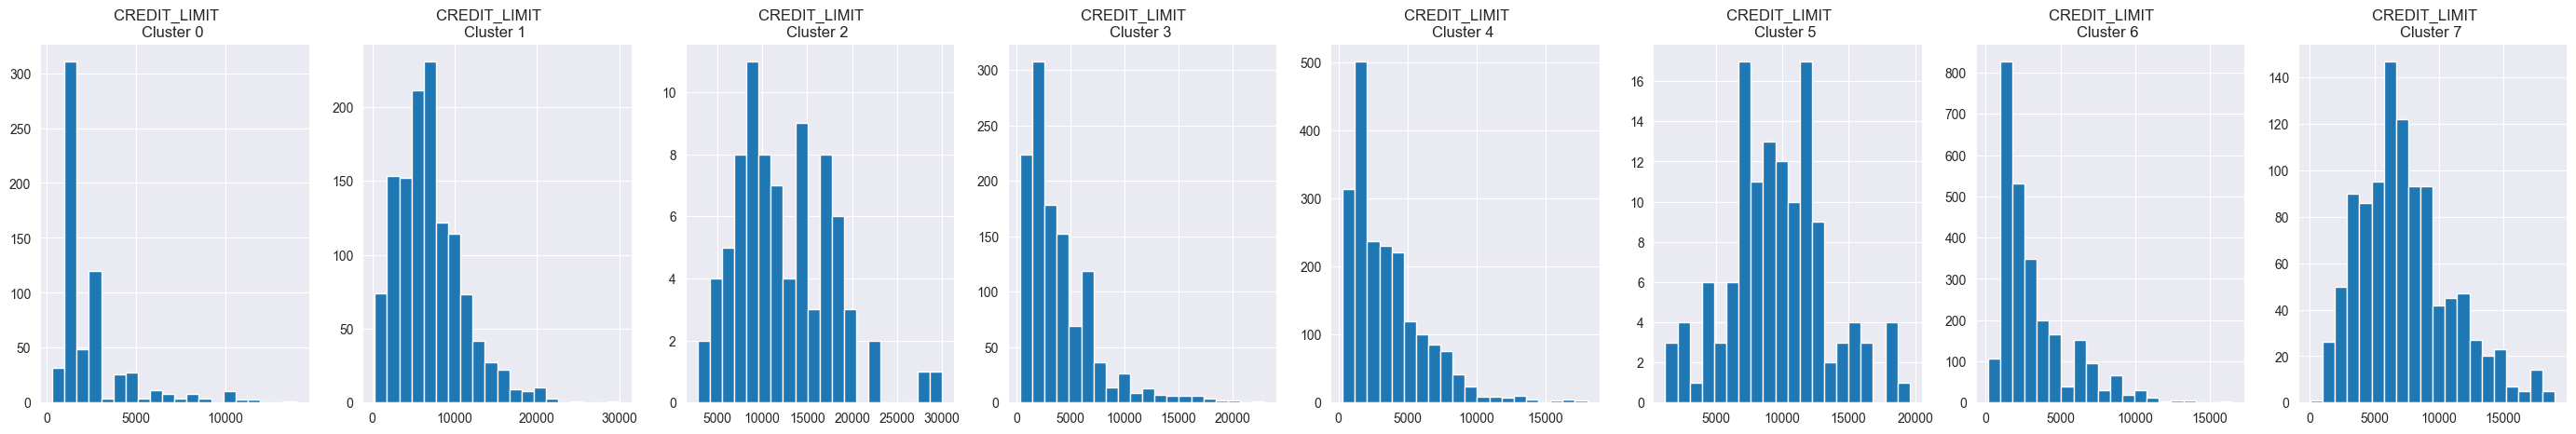

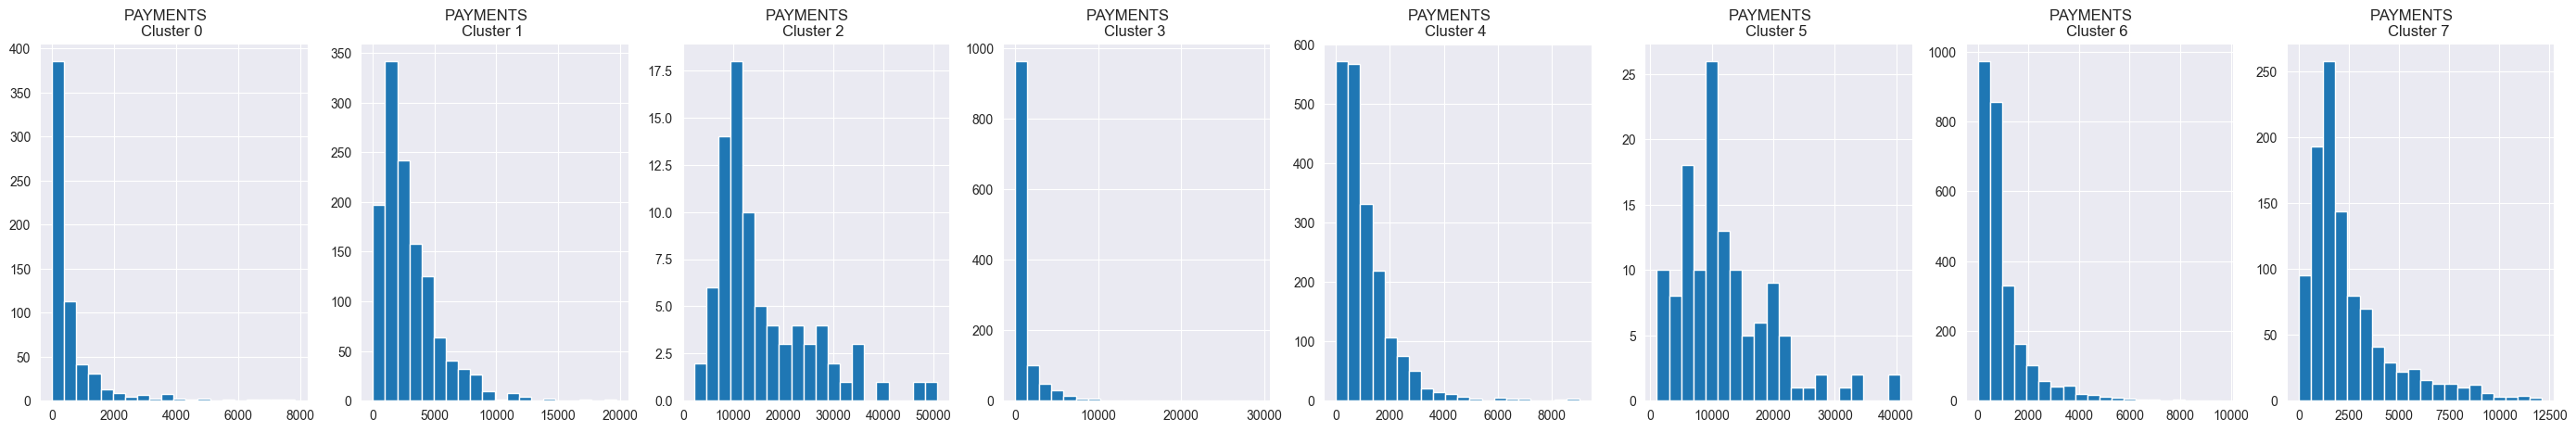

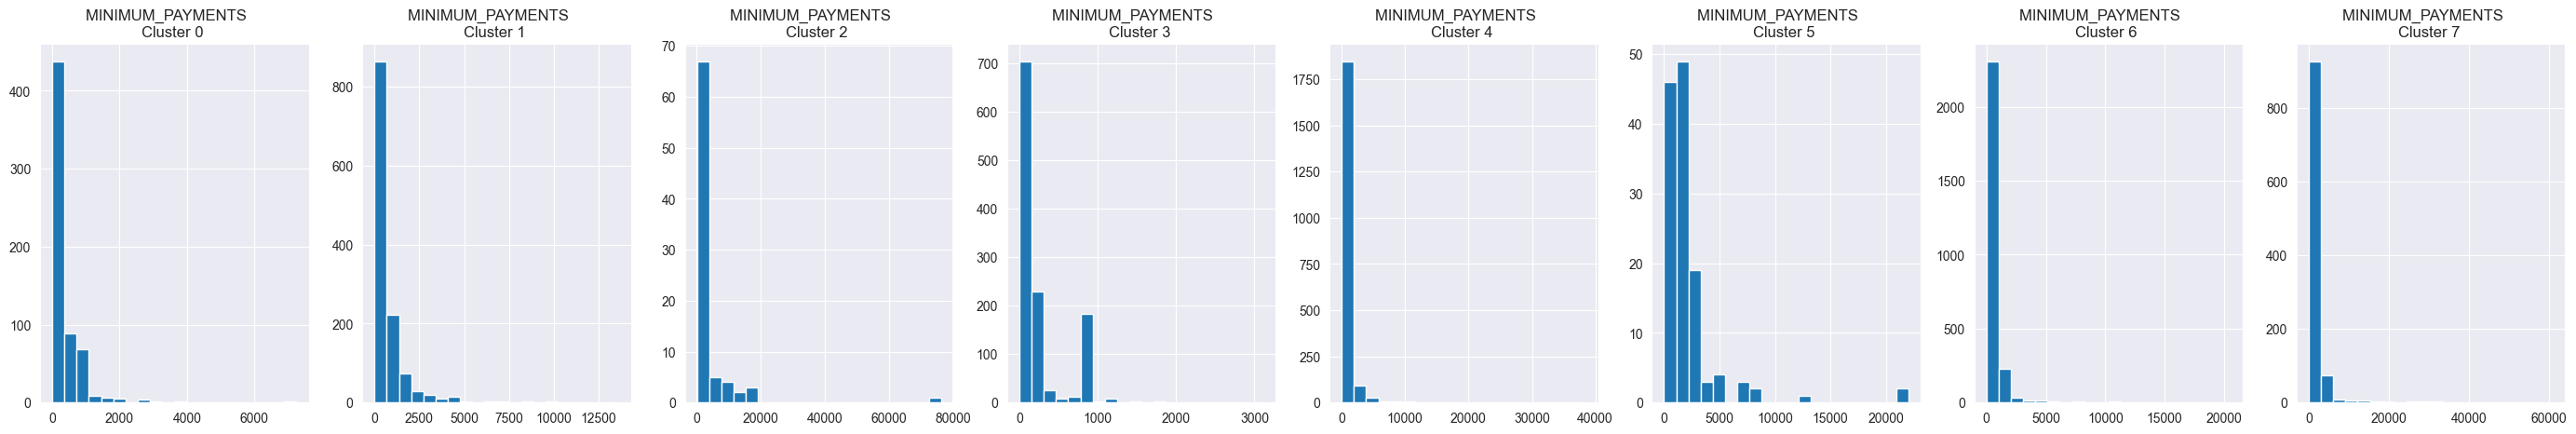

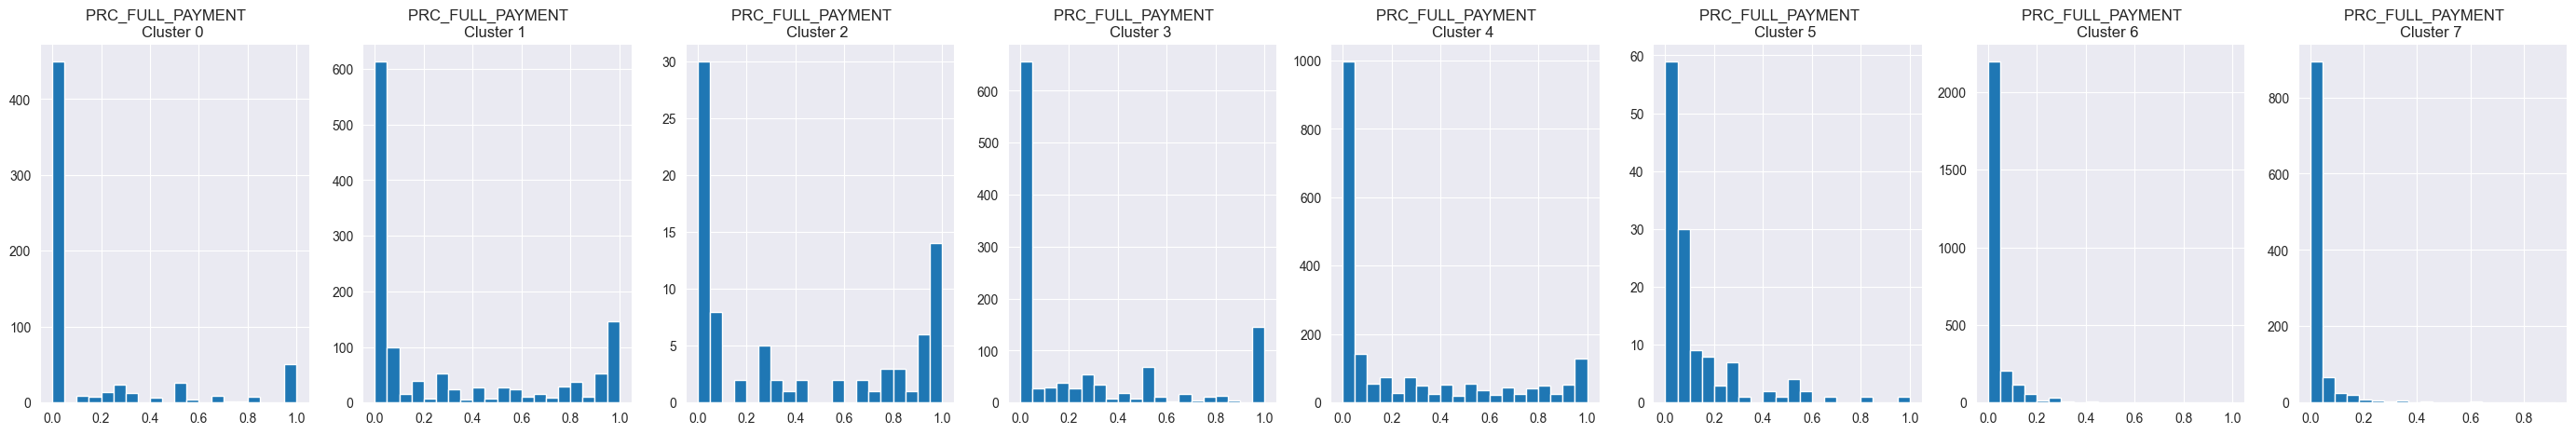

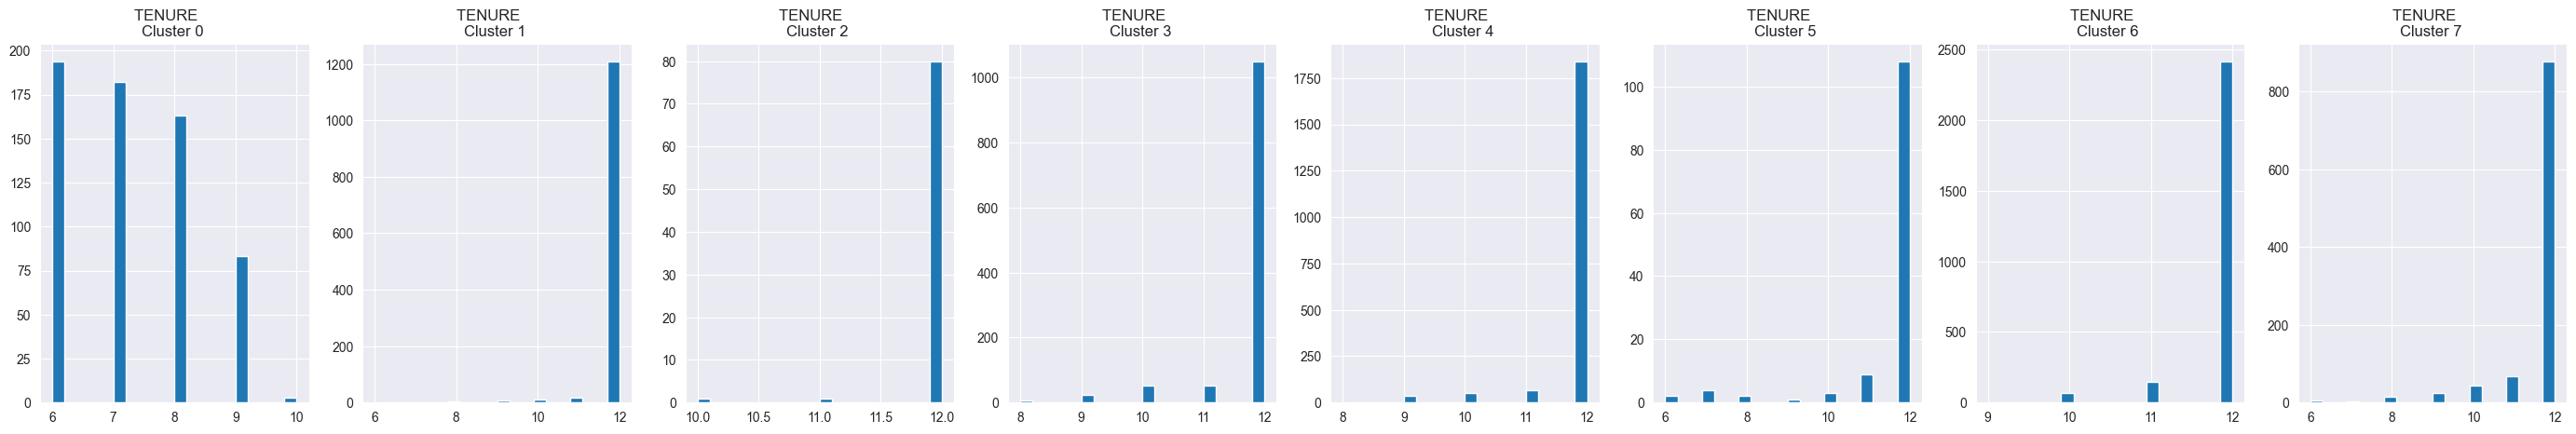

In [51]:
# Plot the histogram of various clusters
for i in creditcard_df.columns:
  plt.figure(figsize = (35, 5))
  for j in range(8):
    plt.subplot(1,8,j+1)
    cluster = creditcard_df_cluster[creditcard_df_cluster['cluster'] == j]
    cluster[i].hist(bins = 20)
    plt.title('{}    \nCluster {} '.format(i,j))

  plt.show()



# TASK 6: APPLY PRINCIPAL COMPONENT ANALYSIS AND VISUALIZE THE RESULTS

The Simple Analogy: "The Flattened Pancake"
Imagine you have a fluffy, 3D pancake (your data) floating in the air. You want to squash it onto a flat plate (2D) without losing its main shape.

To do this best, you wouldn't smash it from the thin side (edge-on) because then it would just look like a line. You would smash it from the widest side (top-down) to capture its full roundness.

Principal Component Analysis (PCA) is the mathematical way of finding that "widest" angle to look at your data so that when you flatten it, you keep the most important information

The Technical Explanation
PCA is a technique used to reduce the number of variables (dimensions) in your data while preserving as much information as possible.​

It works in three main steps:

1. Find the "Best" Angle (Maximize Variance)
Data usually has a "direction" where it spreads out the most. PCA finds this direction and calls it Principal Component 1 (PC1).​

Intuition: If you were photographing a running horse, the "side view" (PC1) gives you the most information about its speed and shape. The "front view" gives you less info.

2. Find the Next Best Angle (Orthogonality)
Once PC1 is found, PCA looks for the next best direction that is completely perpendicular (90 degrees) to the first one. This is PC2.​

Why perpendicular? Because we want new information. If PC2 were parallel to PC1, it would just tell us the same thing we already know.

3. Project and Drop
If you have 100 variables, you can calculate 100 Principal Components. But usually, the first few (e.g., PC1 and PC2) capture 90% of the pattern (variance).

The Magic: You keep just those top 2 components and throw away the other 98. You have now compressed your data from 100 dimensions to 2, making it easy to plot on a graph.​

Key Differences: PCA vs. Autoencoders
While both "compress" data, they do it differently:

PCA is linear. It rotates and flattens data like a pancake. It is fast and simple but cannot capture complex, curved patterns (like a spiral) efficiently.​

Autoencoders are non-linear. They can bend and twist the data (like folding origami) to compress it. They are more powerful but harder to train.

In [54]:
# Obtain the principal components
# Import PCA from the correct module
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
principal_comp = pca.fit_transform(creditcard_df_scaled)
principal_comp

array([[-1.68222026, -1.07645061],
       [-1.1382949 ,  2.50647666],
       [ 0.96968401, -0.3835203 ],
       ...,
       [-0.92620364, -1.8107856 ],
       [-2.33655167, -0.65796601],
       [-0.55642216, -0.40046712]], shape=(8950, 2))

In [55]:
# Create a dataframe with the two components
pca_df = pd.DataFrame(data = principal_comp, columns =['pca1','pca2'])
pca_df.head()

,pca1,pca2
0,-1.682220,-1.076451
1,-1.138295,2.506477
2,0.969684,-0.383520
3,-0.873628,0.043166
4,-1.599434,-0.688581


In [56]:
# Concatenate the clusters labels to the dataframe
pca_df = pd.concat([pca_df,pd.DataFrame({'cluster':labels})], axis = 1)
pca_df.head()

,pca1,pca2,cluster
0,-1.682220,-1.076451,6
1,-1.138295,2.506477,7
2,0.969684,-0.383520,1
3,-0.873628,0.043166,6
4,-1.599434,-0.688581,6


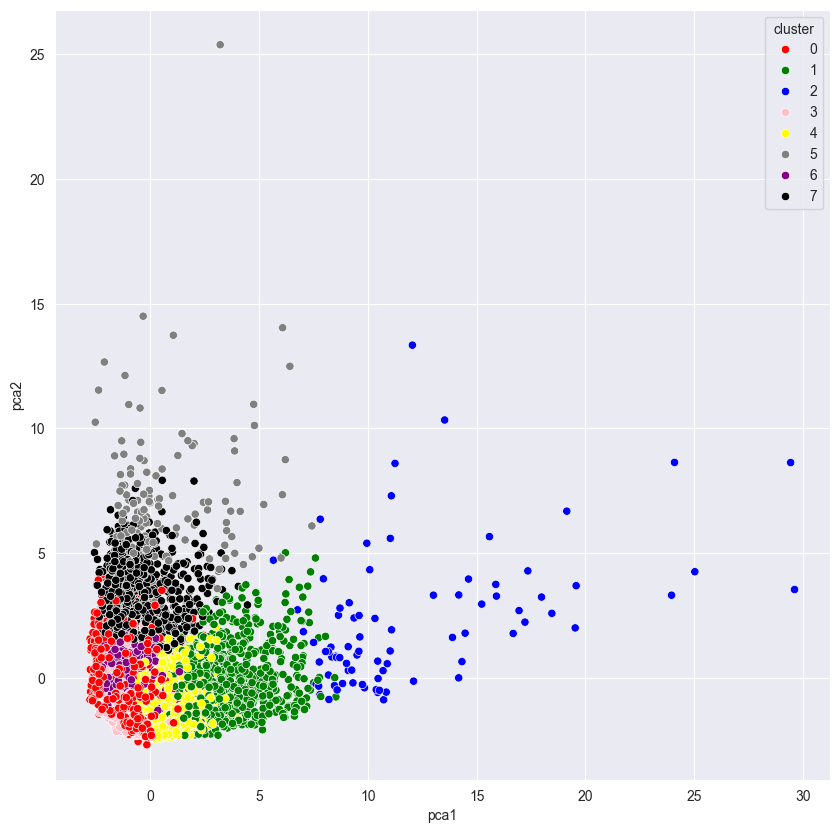

In [57]:
plt.figure(figsize=(10,10))
ax = sns.scatterplot(x="pca1", y="pca2", hue = "cluster", data = pca_df, palette =['red','green','blue','pink','yellow','gray','purple', 'black'])
plt.show()

# TASK #7: UNDERSTAND THE THEORY AND INTUITION BEHIND AUTOENCODERS
The Simple Analogy: "The Summarizing Artist"
Imagine you have a detailed photograph (input data). You hand it to an artist (the Encoder) and ask them to draw a tiny sketch on a small napkin. The napkin is too small to fit every detail, so the artist must decide what matters most: the main shapes, the colors, and the general layout, while ignoring tiny specks of dust or background noise.

This tiny napkin sketch is the compressed representation (or "Bottleneck").

Now, you hand that napkin to a second artist (the Decoder), who has never seen the original photo. Their job is to paint a full-sized recreation of the original image based only on the napkin sketch.

If the system works well, the final painting looks almost identical to the original photo, but "cleaner" because the irrelevant noise didn't fit on the napkin.

The Technical Explanation
An Autoencoder is a neural network trained to copy its input to its output. However, there is a catch: the network has a "narrow" middle section that forces it to compress the data before expanding it back.​

It consists of three parts:

1. The Encoder (Compression)
This part takes the input (like an image or a transaction row) and squeezes it down into a smaller vector of numbers. It removes redundancy and noise, keeping only the most important features (patterns).​

2. The Bottleneck (Latent Space)
This is the middle layer with the fewest neurons. It contains the compressed knowledge of the data. If your input has 100 features but your bottleneck has only 10 neurons, the network must learn to describe the data using only 10 numbers.​

3. The Decoder (Reconstruction)
This part takes the compressed code from the bottleneck and tries to recreate the original input as accurately as possible.

# TASK #8: APPLY AUTOENCODERS (PERFORM DIMENSIONALITY REDUCTION USING AUTOENCODERS)

In [59]:
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from keras.optimizers import SGD

encoding_dim = 7

input_df = Input(shape=(17,))


# Glorot normal initializer (Xavier normal initializer) draws samples from a truncated normal distribution

x = Dense(encoding_dim, activation='relu')(input_df)
x = Dense(500, activation='relu', kernel_initializer = 'glorot_uniform')(x)
x = Dense(500, activation='relu', kernel_initializer = 'glorot_uniform')(x)
x = Dense(2000, activation='relu', kernel_initializer = 'glorot_uniform')(x)

encoded = Dense(10, activation='relu', kernel_initializer = 'glorot_uniform')(x)

x = Dense(2000, activation='relu', kernel_initializer = 'glorot_uniform')(encoded)
x = Dense(500, activation='relu', kernel_initializer = 'glorot_uniform')(x)

decoded = Dense(17, kernel_initializer = 'glorot_uniform')(x)

# autoencoder
autoencoder = Model(input_df, decoded)

#encoder - used for our dimention reduction
encoder = Model(input_df, encoded)

autoencoder.compile(optimizer= 'adam', loss='mean_squared_error')


In [60]:
creditcard_df_scaled.shape

(8950, 17)

In [61]:
autoencoder.fit(creditcard_df_scaled, creditcard_df_scaled, batch_size = 128, epochs = 25,  verbose = 1)

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - loss: 0.5300
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 0.2834
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - loss: 0.2377
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.1838
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.1514
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.1332
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.1252
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.1140
Epoch 9/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.1063
Epoch 10/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0961
Epoch 11/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0889
Epoch 12/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0841
Epoch 13/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0944
Epoch 14/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0804
Epoch 15/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0725


In [66]:
autoencoder.save_weights('autoencoder.weights.h5')


In [67]:
pred = encoder.predict(creditcard_df_scaled)

280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [68]:
pred.shape

(8950, 10)

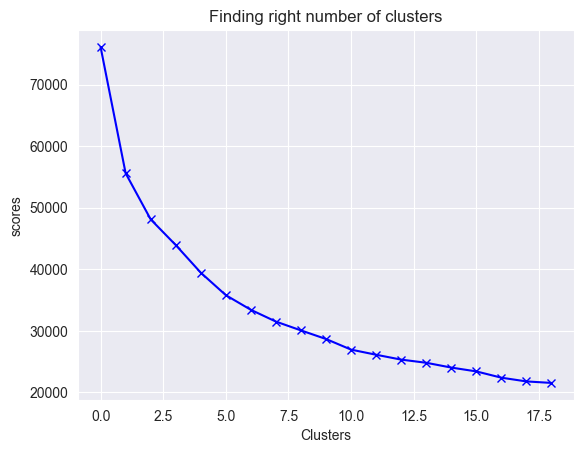

In [69]:
scores_2 = []

range_values = range(1, 20)

for i in range_values:
  kmeans = KMeans(n_clusters= i)
  kmeans.fit(pred)
  scores_2.append(kmeans.inertia_)

plt.plot(scores_2, 'bx-')
plt.title('Finding right number of clusters')
plt.xlabel('Clusters')
plt.ylabel('scores')
plt.show()

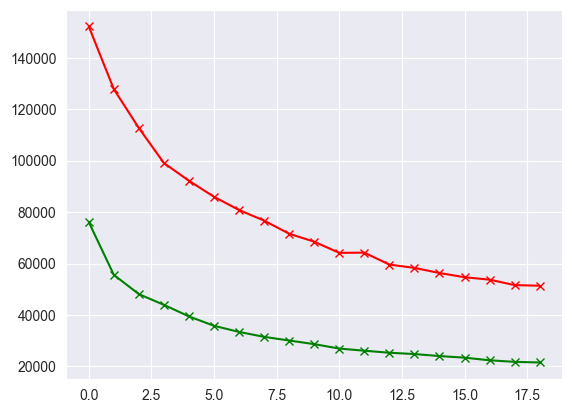

In [71]:
# 'x-' defines the marker (x) and line style (-)
# The color is now handled solely by the color argument
plt.plot(scores_1, 'x-', color = 'r')
plt.plot(scores_2, 'x-', color = 'g')

In [72]:
kmeans = KMeans(4)
kmeans.fit(pred)
labels = kmeans.labels_
y_kmeans = kmeans.fit_predict(creditcard_df_scaled)

In [73]:
df_cluster_dr = pd.concat([creditcard_df, pd.DataFrame({'cluster':labels})], axis = 1)
df_cluster_dr.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


In [74]:
pca = PCA(n_components=2)
prin_comp = pca.fit_transform(pred)
pca_df = pd.DataFrame(data = prin_comp, columns =['pca1','pca2'])
pca_df.head()

,pca1,pca2
0,-1.324172,-0.156084
1,0.825138,-1.264159
2,-0.439720,0.761792
3,-0.726212,-0.129347
4,-1.758457,-0.130569


In [75]:
pca_df = pd.concat([pca_df,pd.DataFrame({'cluster':labels})], axis = 1)
pca_df.head()

,pca1,pca2,cluster
0,-1.324172,-0.156084,1
1,0.825138,-1.264159,0
2,-0.439720,0.761792,1
3,-0.726212,-0.129347,1
4,-1.758457,-0.130569,1


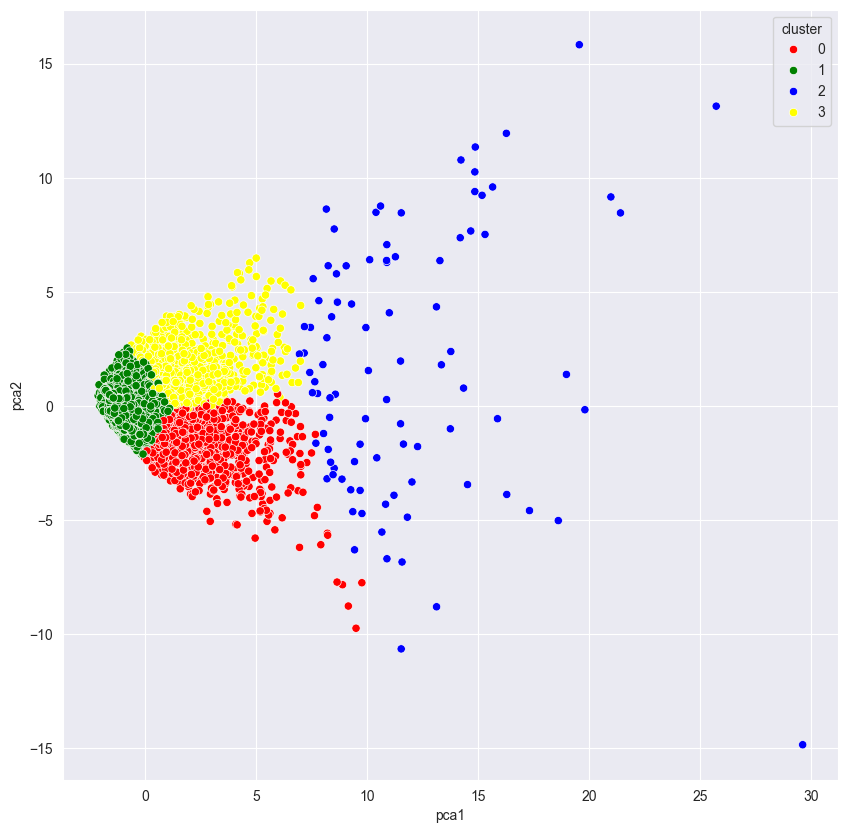

In [76]:
plt.figure(figsize=(10,10))
ax = sns.scatterplot(x="pca1", y="pca2", hue = "cluster", data = pca_df, palette =['red','green','blue','yellow'])
plt.show()

# GOOD JOB!